In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_poisson_deviance

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:
# Load synthetic policy dataset (teammate's traditional GLM simulation output)
df = pd.read_csv("simulation_cohort_results.csv")

# NOTE: this dataset already contains CLAIM_LAMBDA / CLAIM_COUNT / CLAIM_AMOUNT
# generated purely from TRADITIONAL rating factors (age, region, car age, NCD,
# coverage type, flood/theft flags, EV severity multiplier) - there is NO
# behavioral/telemetry signal in these columns. We treat CLAIM_LAMBDA as the
# "traditional-factors-only" baseline risk that a non-telematics insurer would
# be working with. 

print(f"Loaded {len(df):,} policy-year records, {df['POLID'].nunique():,} unique policies, "
      f"years {df['SIM_YEAR'].min()}-{df['SIM_YEAR'].max()}")


Loaded 328,105 policy-year records, 105,000 unique policies, years 2026-2045


In [ ]:
# STEP 1: Simulate driving-behavior telemetry independently of CLAIM_LAMBDA

# ASSUMPTION A1: Raw telemetry (hard braking, speeding, night driving) is drawn
# from its own distributions, NOT derived from CLAIM_LAMBDA or CLAIM_COUNT.
# We allow only a mild, literature-consistent nudge from driver age (younger
# drivers trend slightly more aggressive on average) so the simulation isn't
# unrealistically orthogonal to demographics - but the dominant source of
# variation is independent random heterogeneity, representing genuine
# behavioral differences the GLM cannot see.

telem_rng = np.random.default_rng(2026)

age_z = (df["DRIVER_AGE"] - df["DRIVER_AGE"].mean()) / df["DRIVER_AGE"].std()

df["hard_braking_per_100km"] = np.clip(
    telem_rng.gamma(shape=2.0, scale=1.8, size=len(df)) - 0.15 * age_z, 0, 15
)
df["speeding_pct"] = np.clip(
    telem_rng.gamma(shape=2.0, scale=6.0, size=len(df)) - 1.0 * age_z, 0, 50
)
df["night_driving_pct"] = np.clip(
    telem_rng.beta(a=2, b=5, size=len(df)) * 40 - 1.5 * age_z, 0, 50
)

# ASSUMPTION A2: Composite telematics_score (20-100, 100 = safest) is built
# bottom-up FROM the raw telemetry above (not from claims data). Weights
# (0.45 / 0.40 / 0.15) approximate published UBI risk-elasticity ordering -
# harsh braking and speeding dominate, night driving contributes less.

def _minmax(s):
    return (s - s.min()) / (s.max() - s.min())

behavior_risk_raw = (
    0.45 * _minmax(df["hard_braking_per_100km"])
    + 0.40 * _minmax(df["speeding_pct"])
    + 0.15 * _minmax(df["night_driving_pct"])
)
df["telematics_score"] = np.clip(100 - behavior_risk_raw * 80, 20, 100)

# STEP 2: Layer a behavioral risk multiplier ON TOP of the traditional
# (GLM-observable) baseline, then regenerate claims under this richer,
# more realistic world.

# ASSUMPTION A3: Behavior explains genuine WITHIN-segment claim variance that
# demographic factors alone cannot. Multiplier ranges ~0.7x (very safe driver)
# to ~1.5x (very risky driver), centered near 1.0 so the portfolio-level mean
# claim frequency stays close to the original GLM calibration.
behavior_multiplier = 0.7 + 0.8 * (1 - _minmax(df["telematics_score"]))
df["BEHAVIOR_MULTIPLIER"] = behavior_multiplier

# CLAIM_LAMBDA_TRUE = traditional-factor baseline x independent behavioral signal.
# This is the "ground truth" of a world where driving behavior genuinely
# matters - the traditional GLM only ever sees the CLAIM_LAMBDA component.
df["CLAIM_LAMBDA_TRUE"] = df["CLAIM_LAMBDA"] * behavior_multiplier

claim_rng = np.random.default_rng(77)
df["CLAIM_COUNT_TRUE"] = claim_rng.poisson(df["CLAIM_LAMBDA_TRUE"])

# ASSUMPTION A4: Severity mechanics (peril mix, EV repair-cost factor, SA caps)
# are INHERITED from the teammate's per-peril Gamma severity model rather than
# reinvented - we bootstrap new claim amounts from the empirical distribution
# of ACTUAL claimant severities already produced by that model. This keeps the
# two approaches consistent on "how much a claim costs" and isolates the
# comparison to "how well can each model predict WHO claims."
claimant_severity = df.loc[df["CLAIM_AMOUNT"] > 0, "CLAIM_AMOUNT"].values

sev_rng = np.random.default_rng(88)
counts = df["CLAIM_COUNT_TRUE"].values
claim_mask = counts > 0
amount_true = np.zeros(len(df))
if claim_mask.any():
    idx_repeat = np.repeat(np.flatnonzero(claim_mask), counts[claim_mask])
    draws = sev_rng.choice(claimant_severity, size=len(idx_repeat), replace=True)
    np.add.at(amount_true, idx_repeat, draws)
df["CLAIM_AMOUNT_TRUE"] = amount_true
df["CLAIM_OCCURRED_TRUE"] = df["CLAIM_COUNT_TRUE"] > 0

# Category binning for diagnostic heatmaps
df["age_group"] = pd.cut(
    df["DRIVER_AGE"],
    bins=[17, 25, 35, 50, 65, 100],
    labels=["18-25", "26-35", "36-50", "51-65", "65+"],
)
df["telem_bin"] = pd.cut(
    df["telematics_score"],
    bins=[0, 50, 70, 85, 100],
    labels=["<50 (High Risk)", "50-70 (Moderate)", "70-85 (Low Risk)", "85-100 (Safe)"],
)

print("Independent telemetry + re-simulated 'true' claims world built.")
print(f"  Original portfolio claim frequency (traditional-only) : {(df['CLAIM_COUNT'] > 0).mean():.2%}")
print(f"  'True' portfolio claim frequency (+ behavior)          : {df['CLAIM_OCCURRED_TRUE'].mean():.2%}")
print(f"  Original total claim amount : RM{df['CLAIM_AMOUNT'].sum():,.0f}")
print(f"  'True' total claim amount   : RM{df['CLAIM_AMOUNT_TRUE'].sum():,.0f}")
print(f"  Behavior multiplier range  : {behavior_multiplier.min():.2f}x - {behavior_multiplier.max():.2f}x "
      f"(mean {behavior_multiplier.mean():.2f}x)")


Independent telemetry + re-simulated 'true' claims world built.
  Original portfolio claim frequency (traditional-only) : 13.87%
  'True' portfolio claim frequency (+ behavior)          : 12.80%
  Original total claim amount : RM316,395,484
  'True' total claim amount   : RM310,328,934
  Behavior multiplier range  : 0.70x - 1.50x (mean 0.91x)


In [ ]:
# STEP 3: Fair head-to-head - two models predicting the SAME target
# (CLAIM_COUNT_TRUE), one restricted to traditional factors (the GLM's
# information set), one with telemetry added on top.

# ASSUMPTION A5: Train/test split is GROUPED by POLID.
# The dataset pools up to 20 policy-years per policy; a random split would let
# the same policy's risk profile leak between train and test and inflate both
# models' apparent accuracy. Grouping helps us force genuinely unseen policies into test.

glm_features = ["DRIVER_AGE", "CAR_AGE", "NCD_LEVEL"]  # traditional / demographic-only
telematics_features = glm_features + [
    "hard_braking_per_100km", "speeding_pct", "night_driving_pct"
]

y = df["CLAIM_COUNT_TRUE"]
groups = df["POLID"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, y, groups=groups))

X_train_glm, X_test_glm = df.iloc[train_idx][glm_features], df.iloc[test_idx][glm_features]
X_train_tel, X_test_tel = df.iloc[train_idx][telematics_features], df.iloc[test_idx][telematics_features]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

glm_model = PoissonRegressor(alpha=1e-3, max_iter=1000).fit(X_train_glm, y_train)
tel_model = PoissonRegressor(alpha=1e-3, max_iter=1000).fit(X_train_tel, y_train)

y_pred_glm_test = glm_model.predict(X_test_glm)
y_pred_tel_test = tel_model.predict(X_test_tel)

# Full-dataset predictions, used for pricing + heatmaps below
df["pred_freq_glm"] = glm_model.predict(df[glm_features])
df["pred_freq_telematics"] = tel_model.predict(df[telematics_features])

print(f"Train: {len(train_idx):,} rows ({df.iloc[train_idx]['POLID'].nunique():,} policies) | "
      f"Test: {len(test_idx):,} rows ({df.iloc[test_idx]['POLID'].nunique():,} policies)")
print("Traditional-factors-only model features :", glm_features)
print("Telematics-enhanced model features       :", telematics_features)


Train: 262,658 rows (84,000 policies) | Test: 65,447 rows (21,000 policies)
Traditional-factors-only model features : ['DRIVER_AGE', 'CAR_AGE', 'NCD_LEVEL']
Telematics-enhanced model features       : ['DRIVER_AGE', 'CAR_AGE', 'NCD_LEVEL', 'hard_braking_per_100km', 'speeding_pct', 'night_driving_pct']


In [ ]:
# STEP 4: Premium calculation - uses each model's OWN predicted frequency
# (pred_freq_glm / pred_freq_telematics), never the oracle CLAIM_LAMBDA.

# ASSUMPTION A6: Average severity per claim is calibrated from the empirical
# claimant severity distribution (data-driven), not an arbitrary flat 12% of
# sum assured. Target loss ratio set to 65% to mirror the traditional insurer's target book LR.
TARGET_LOSS_RATIO = 0.65
avg_severity_per_claim = claimant_severity.mean()
print(f"Empirical average severity per claim: RM{avg_severity_per_claim:,.0f}")

for label, freq_col in [("glm", "pred_freq_glm"), ("telematics", "pred_freq_telematics")]:
    df[f"expected_loss_{label}"] = df[freq_col] * avg_severity_per_claim
    df[f"pure_premium_{label}"] = df[f"expected_loss_{label}"] / TARGET_LOSS_RATIO
    df[f"final_premium_{label}"] = (
        df[f"pure_premium_{label}"] * df["TOTAL_LOADING"] * 1.08  # + 8% SST
    )

print(f"Avg traditional-factor premium : RM{df['final_premium_glm'].mean():,.2f}")
print(f"Avg telematics-enhanced premium: RM{df['final_premium_telematics'].mean():,.2f}")


Empirical average severity per claim: RM6,952
Avg traditional-factor premium : RM2,011.36
Avg telematics-enhanced premium: RM2,011.44


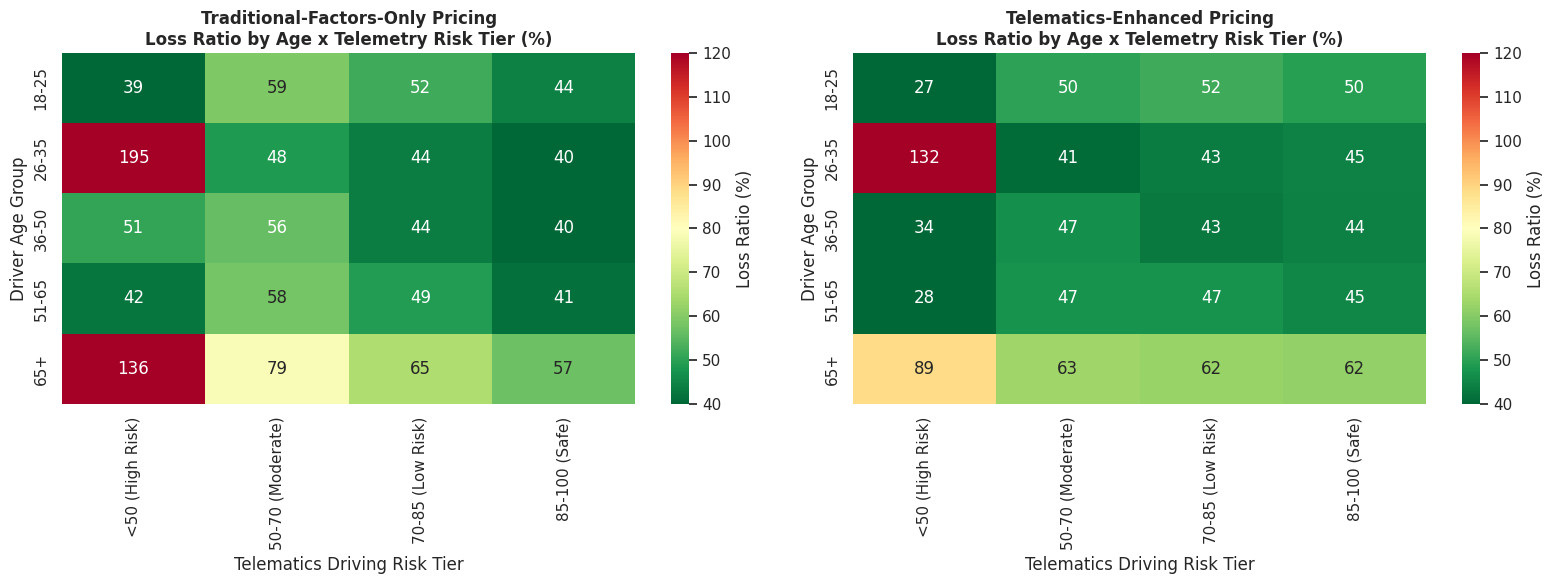

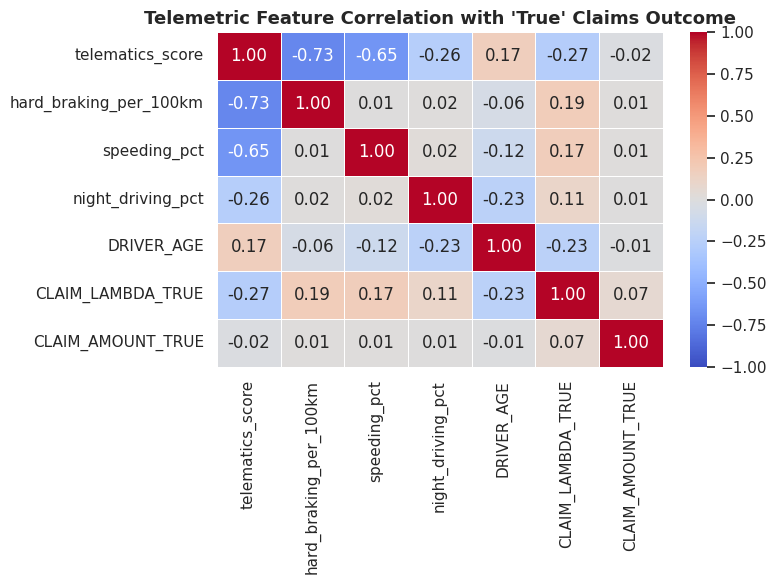

In [ ]:
# STEP 5: Visualizations - loss ratio uses CLAIM_AMOUNT_TRUE throughout, so
# both models are graded against the SAME realized ("true") claims experience.

# --- Chart 1: Loss ratio heatmap, side by side (traditional vs telematics) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, title in [
    (axes[0], "glm", "Traditional-Factors-Only Pricing"),
    (axes[1], "telematics", "Telematics-Enhanced Pricing"),
]:
    pivot = df.pivot_table(
        index="age_group", columns="telem_bin",
        values=["CLAIM_AMOUNT_TRUE", f"final_premium_{label}"],
        aggfunc="sum", observed=False,
    )
    lr = (pivot["CLAIM_AMOUNT_TRUE"] / pivot[f"final_premium_{label}"]) * 100
    sns.heatmap(lr, annot=True, fmt=".0f", cmap="RdYlGn_r", ax=ax,
                cbar_kws={"label": "Loss Ratio (%)"}, vmin=40, vmax=120)
    ax.set_title(f"{title}\nLoss Ratio by Age x Telemetry Risk Tier (%)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Telematics Driving Risk Tier")
    ax.set_ylabel("Driver Age Group")

plt.tight_layout()
plt.savefig("images/loss_ratio_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Interpretation note: the traditional panel varies mainly by AGE ROW (since it
# has no telemetry input at all - columns are near-flat within each row); the
# telematics panel should show genuine variation ACROSS COLUMNS too, i.e. loss
# ratio differs by driving-risk tier even within the same age group. That
# cross-column spread is the visual proof telemetrics adds information the
# traditional GLM cannot see.

# --- Chart 2: Telemetric feature correlation with the TRUE claims outcome ---
corr_cols = [
    "telematics_score", "hard_braking_per_100km", "speeding_pct",
    "night_driving_pct", "DRIVER_AGE", "CLAIM_LAMBDA_TRUE", "CLAIM_AMOUNT_TRUE",
]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Telemetric Feature Correlation with 'True' Claims Outcome", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/telemetry_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


=== HEAD-TO-HEAD MODEL COMPARISON (same held-out policies, same 'true' outcome) ===
                                 Model  Mean Poisson Deviance (test)  Gini Index (test)  Overall Loss Ratio (%)
Traditional GLM (age/car age/NCD only)                        0.5729             0.0823                 47.0239
                   Telematics-Enhanced                        0.5720             0.0905                 47.0220

Gini lift from adding telemetry: +0.0082 (10.0% relative improvement)


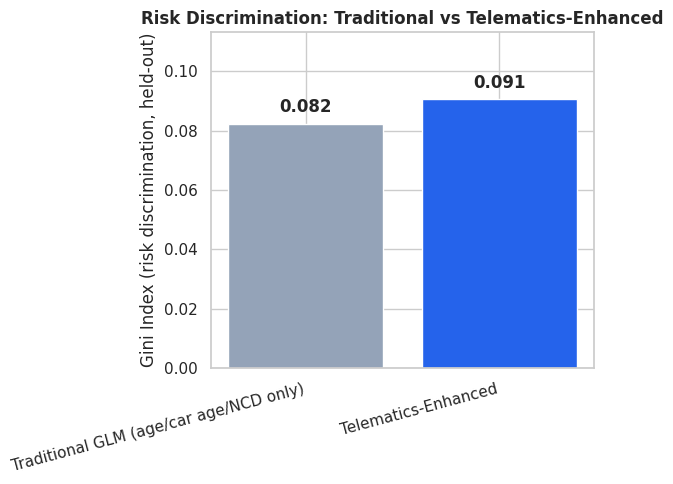


=== TELEMATICS MODEL COEFFICIENTS ===
               Feature  Poisson Coefficient
hard_braking_per_100km             0.028821
          speeding_pct             0.006993
     night_driving_pct             0.003194
            DRIVER_AGE            -0.004186
               CAR_AGE            -0.005550
             NCD_LEVEL            -0.500235


In [7]:
# ============================================================================
# STEP 6: Head-to-head model performance - Gini, Poisson deviance, loss ratio
# ============================================================================

def calculate_gini(y_true, y_pred):
    d = pd.DataFrame({"true": y_true, "pred": y_pred}).sort_values("pred", ascending=False)
    total_claims = d["true"].sum()
    cum_claims = d["true"].cumsum() / total_claims
    cum_pop = np.arange(1, len(d) + 1) / len(d)
    trapz_func = getattr(np, "trapezoid", getattr(np, "trapz", None))
    return 2 * trapz_func(cum_claims, cum_pop) - 1

results = []
for label, y_pred_test, pred_col in [
    ("Traditional GLM (age/car age/NCD only)", y_pred_glm_test, "pred_freq_glm"),
    ("Telematics-Enhanced", y_pred_tel_test, "pred_freq_telematics"),
]:
    dev = mean_poisson_deviance(y_test, y_pred_test)
    gini = calculate_gini(y_test, y_pred_test)
    lr = (df["CLAIM_AMOUNT_TRUE"].sum() / df[f"final_premium_{'glm' if 'GLM' in label else 'telematics'}"].sum()) * 100
    results.append({"Model": label, "Mean Poisson Deviance (test)": dev,
                    "Gini Index (test)": gini, "Overall Loss Ratio (%)": lr})

results_df = pd.DataFrame(results)
print("=== HEAD-TO-HEAD MODEL COMPARISON (same held-out policies, same 'true' outcome) ===")
print(results_df.round(4).to_string(index=False))

gini_lift = results_df.loc[1, "Gini Index (test)"] - results_df.loc[0, "Gini Index (test)"]
print(f"\nGini lift from adding telemetry: +{gini_lift:.4f} "
      f"({gini_lift / results_df.loc[0, 'Gini Index (test)'] * 100:.1f}% relative improvement)")

# --- Chart: Gini comparison bar ---
plt.figure(figsize=(6, 5))
bars = plt.bar(results_df["Model"], results_df["Gini Index (test)"],
                color=["#94a3b8", "#2563eb"])
plt.ylabel("Gini Index (risk discrimination, held-out)")
plt.title("Risk Discrimination: Traditional vs Telematics-Enhanced", fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, results_df["Gini Index (test)"].max() * 1.25)
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.004,
              f"{b.get_height():.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("images/gini_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Model coefficients (telematics model) - feature importance for the deck
coef_df = pd.DataFrame({
    "Feature": telematics_features,
    "Poisson Coefficient": tel_model.coef_,
}).sort_values("Poisson Coefficient", ascending=False)
print("\n=== TELEMATICS MODEL COEFFICIENTS ===")
print(coef_df.to_string(index=False))
